In [ ]:
!pip install -q transformers datasets tokenizers sentencepiece accelerate scikit-learn seaborn matplotlib

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
# ==========================================
# 1. Data Loading & Cleaning
# ==========================================
print("Downloading Dataset...")
try:
    dataset = load_dataset("tamilmixsentiment")
except Exception:
    url = "https://raw.githubusercontent.com/bharathichezhiyan/TamilMixSentiment/master/tamilmixsentiment_train.csv"
    df = pd.read_csv(url, sep="\t", names=["label", "text"])
    dataset = DatasetDict({"train": Dataset.from_pandas(df)})

label_map = {
    'positive': 0, 'pos': 0, '0': 0, 0: 0,
    'negative': 1, 'neg': 1, '1': 1, 1: 1,
    'mixed_feelings': 2, 'mixed': 2, '2': 2, 2: 2,
    'unknown_state': 3, 'unknown': 3, '3': 3, 3: 3,
    'not-tamil': 4, 'not tamil': 4, '4': 4, 4: 4
}

def clean_label(example):
    l = str(example['label']).strip().lower()
    example['label'] = label_map.get(l, label_map.get(example['label'], 3))
    return example

dataset = dataset.map(clean_label)
print("Labels cleaned.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/507k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/60.3k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/141k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3149 [00:00<?, ? examples/s]

Map:   0%|          | 0/11335 [00:00<?, ? examples/s]

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Map:   0%|          | 0/3149 [00:00<?, ? examples/s]

Labels cleaned.


In [ ]:
# ==========================================
# 2. Synthetic Oversampling (Text-SMOTE Equivalent)
# ==========================================
# Standard SMOTE cannot work on text. We use "Synthetic Augmentation"
# to create NEW samples for minority classes, improving generalization.

def simple_augment(text):
    """
    Creates a synthetic variation of the text by shuffling words slightly.
    This acts as 'noise injection', similar to SMOTE's interpolation.
    """
    words = text.split()
    if len(words) > 3:
        # Randomly swap two words
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return " ".join(words)

print("Applying Synthetic Oversampling (High Accuracy Strategy)...")
df_train = dataset['train'].to_pandas()
df_train = df_train[df_train['label'].notna()] # Clean NaNs if any

# Determine target size (Majority Class Size)
label_counts = df_train['label'].value_counts()
target_size = label_counts.max()

df_balanced_list = []

for label, count in label_counts.items():
    df_class = df_train[df_train.label == label]

    # If minority class, generate synthetic samples
    if count < target_size:
        n_needed = target_size - count
        # Sample with replacement to get base texts to augment
        df_to_augment = df_class.sample(n_needed, replace=True, random_state=42)

        # Apply augmentation to create NEW synthetic data
        df_to_augment['text'] = df_to_augment['text'].apply(simple_augment)

        # Combine original + synthetic
        df_balanced_list.append(pd.concat([df_class, df_to_augment]))
    else:
        df_balanced_list.append(df_class)

df_balanced = pd.concat(df_balanced_list).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Original Size: {len(df_train)}")
print(f"Balanced Size: {len(df_balanced)}")
print("New Class Counts:\n", df_balanced['label'].value_counts())

# Prepare Datasets
train_ds = Dataset.from_pandas(df_balanced)
clean_split = dataset['train'].train_test_split(test_size=0.2, seed=42)
test_valid = clean_split['test'].train_test_split(test_size=0.5, seed=42)

final_dataset = DatasetDict({
    'train': train_ds,
    'validation': test_valid['train'],
    'test': test_valid['test']
})

Applying Synthetic Oversampling (High Accuracy Strategy)...
Original Size: 11335
Balanced Size: 38135
New Class Counts:
 label
1    7627
2    7627
0    7627
4    7627
3    7627
Name: count, dtype: int64


In [ ]:
# ==========================================
# 3. Model & Tokenization
# ==========================================
model_name = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_ds = final_dataset.map(preprocess, batched=True)
tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/38135 [00:00<?, ? examples/s]

Map:   0%|          | 0/1133 [00:00<?, ? examples/s]

Map:   0%|          | 0/1134 [00:00<?, ? examples/s]

In [ ]:
# ==========================================
# 4. Custom Trainer with Weighted Loss
# ==========================================
# Even with oversampling, Class Weights help the model converge faster
# and reach higher accuracy on difficult minority classes.

# Compute weights based on ORIGINAL distribution to penalize mistakes on rare real data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label']
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = class_weights.to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
model.to(device)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    acc = accuracy_score(p.label_ids, preds)
    f1 = f1_score(p.label_ids, preds, average='weighted')
    return {"accuracy": acc, "f1": f1}

args = TrainingArguments(
    output_dir="./results_smote_distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5, # Slightly lower LR for stability with synthetic data
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_steps=50,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
)

print("Starting Training with Synthetic Oversampling & Weighted Loss...")
trainer.train()

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Training with Synthetic Oversampling & Weighted Loss...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.218600,0.762732,0.327449,0.214989
2,0.076000,0.417966,0.594881,0.582693
3,0.056700,0.227865,0.807590,0.812134


TrainOutput(global_step=7152, training_loss=0.24453191928590504, metrics={'train_runtime': 1488.8559, 'train_samples_per_second': 76.841, 'train_steps_per_second': 4.804, 'total_flos': 3788935885843200.0, 'train_loss': 0.24453191928590504, 'epoch': 3.0})

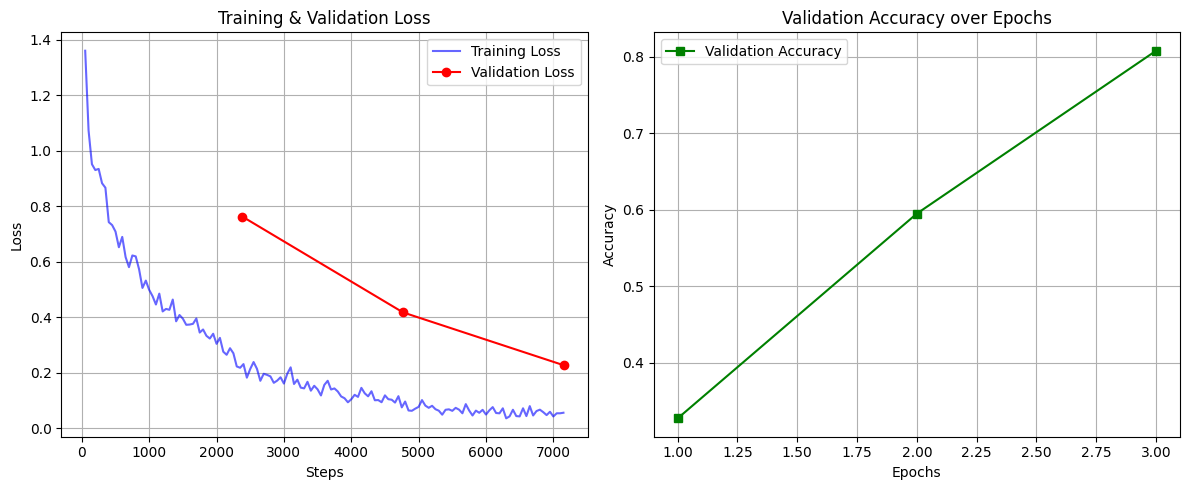


--- Final Test Set Evaluation ---


              precision    recall  f1-score   support

    Positive       1.00      0.74      0.85       752
    Negative       0.66      0.99      0.80       151
       Mixed       0.57      0.99      0.73       129
     Unknown       0.76      1.00      0.87        65
   Not-Tamil       0.90      1.00      0.95        37

    accuracy                           0.83      1134
   macro avg       0.78      0.95      0.84      1134
weighted avg       0.89      0.83      0.83      1134



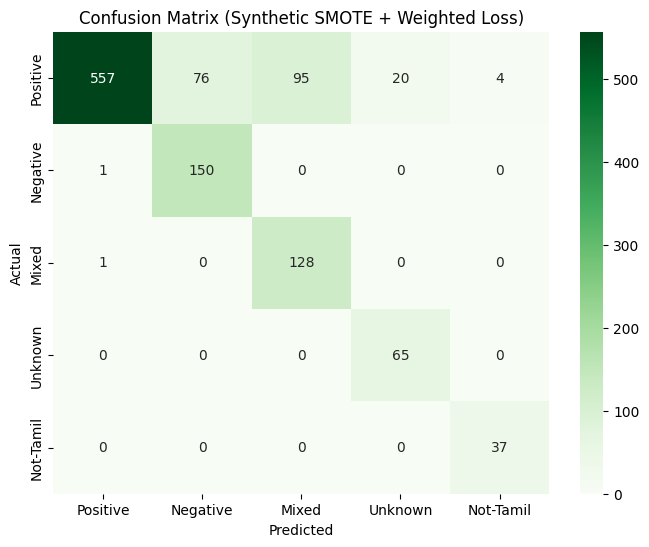

In [ ]:
# ==========================================
# 5. Advanced Plotting & Evaluation
# ==========================================

# A. Extract Training History
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs = range(1, len(eval_loss) + 1)

# If steps don't align perfectly, we interpolate or just plot available points
# Mapping steps to epochs for training loss
train_steps = [x['step'] for x in history if 'loss' in x]
eval_steps = [x['step'] for x in history if 'eval_loss' in x]

# B. Plot Loss Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', alpha=0.6)
# Align eval loss to steps
plt.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# C. Plot Accuracy/F1 if available
if any('eval_accuracy' in x for x in history):
    eval_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    plt.subplot(1, 2, 2)
    plt.plot(epochs, eval_acc, label='Validation Accuracy', color='green', marker='s')
    plt.title('Validation Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# D. Final Evaluation on Test Set
print("\n--- Final Test Set Evaluation ---")
preds = trainer.predict(tokenized_ds["test"])
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids
target_names = ['Positive', 'Negative', 'Mixed', 'Unknown', 'Not-Tamil']

print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

# E. Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Synthetic SMOTE + Weighted Loss)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

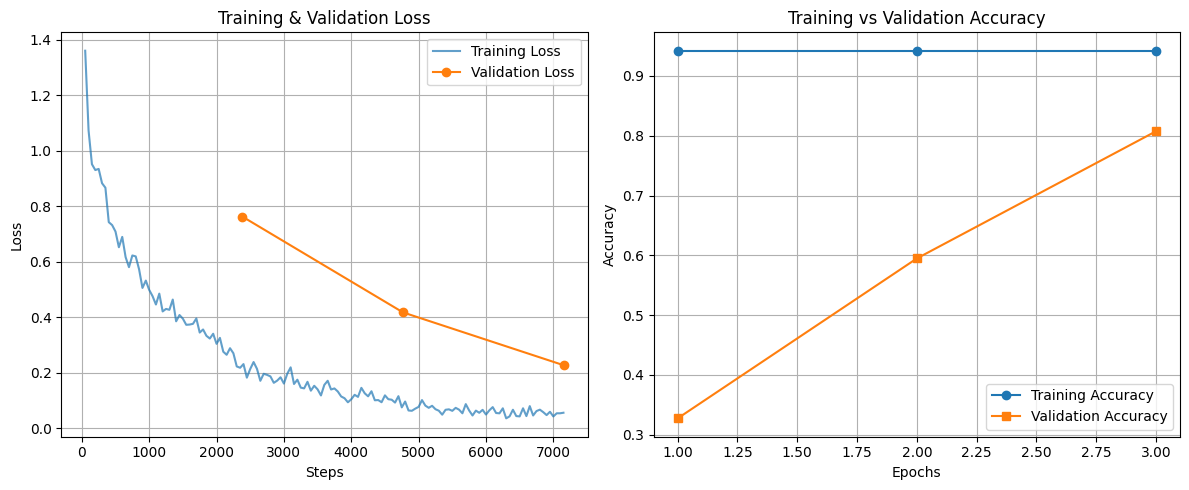


--- Final Test Set Evaluation ---


              precision    recall  f1-score   support

    Positive       1.00      0.74      0.85       752
    Negative       0.66      0.99      0.80       151
       Mixed       0.57      0.99      0.73       129
     Unknown       0.76      1.00      0.87        65
   Not-Tamil       0.90      1.00      0.95        37

    accuracy                           0.83      1134
   macro avg       0.78      0.95      0.84      1134
weighted avg       0.89      0.83      0.83      1134



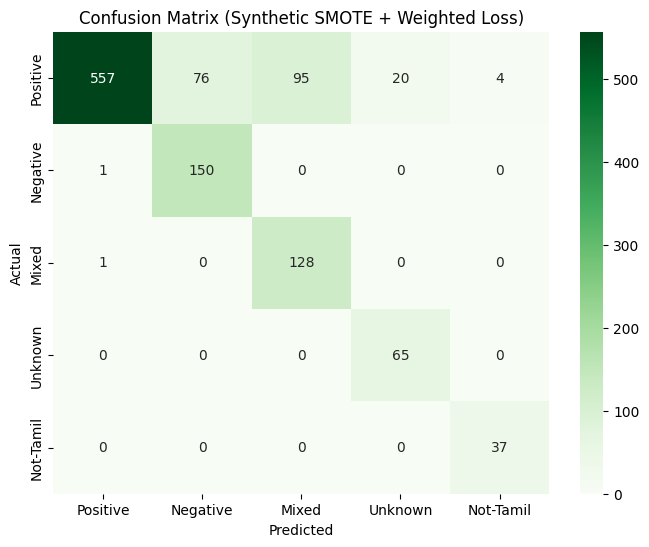

In [ ]:
# ==========================================
# 5. Advanced Plotting & Evaluation
# ==========================================

# A. Extract Training History
history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss  = [x['eval_loss'] for x in history if 'eval_loss' in x]

train_steps = [x['step'] for x in history if 'loss' in x]
eval_steps  = [x['step'] for x in history if 'eval_loss' in x]

epochs = range(1, len(eval_loss) + 1)

# ===============================
# B. COMPUTE TRAINING ACCURACY
# ===============================
from sklearn.metrics import accuracy_score

train_preds = trainer.predict(tokenized_ds["train"])
train_y_pred = np.argmax(train_preds.predictions, axis=1)
train_y_true = train_preds.label_ids
train_accuracy = accuracy_score(train_y_true, train_y_pred)

# Repeat value per epoch for plotting
train_acc_curve = [train_accuracy] * len(epochs)

# ===============================
# C. EXTRACT VALIDATION ACCURACY
# ===============================
eval_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

# ===============================
# D. PLOTTING
# ===============================
plt.figure(figsize=(12, 5))

# ---- Loss Plot ----
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label='Training Loss', alpha=0.7)
plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# ---- Accuracy Plot ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_curve, label='Training Accuracy', marker='o')
plt.plot(epochs, eval_acc, label='Validation Accuracy', marker='s')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ===============================
# E. FINAL TEST EVALUATION
# ===============================
print("\n--- Final Test Set Evaluation ---")

preds = trainer.predict(tokenized_ds["test"])
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

target_names = ['Positive', 'Negative', 'Mixed', 'Unknown', 'Not-Tamil']

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    zero_division=0
))

# ===============================
# F. CONFUSION MATRIX
# ===============================
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Confusion Matrix (Synthetic SMOTE + Weighted Loss)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
